In [1]:
!pip install torch pandas numpy matplotlib

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   --------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

print("PyTorch version:", torch.__version__)
print("All imports successful!")

PyTorch version: 2.13.0+cpu
All imports successful!


In [3]:
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [4]:
df = pd.read_csv("Loan_default.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (255347, 18)

Columns:
['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']

First 5 rows:


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [5]:
print("Target column values:")
print(df["Default"].value_counts())

print("\nTarget data type:")
print(df["Default"].dtype)

Target column values:
Default
0    225694
1     29653
Name: count, dtype: int64

Target data type:
int64


In [6]:
X = df.drop(columns=["Default"])
y = df["Default"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (255347, 17)
y shape: (255347,)


In [7]:
if "LoanID" in X.columns:
    X = X.drop(columns=["LoanID"])

print("X shape after removing LoanID:", X.shape)

X shape after removing LoanID: (255347, 16)


In [8]:
X = pd.get_dummies(X, drop_first=True)

print("X shape after encoding:", X.shape)
print("\nData types:")
print(X.dtypes.value_counts())

X shape after encoding: (255347, 24)

Data types:
bool       15
int64       7
float64     2
Name: count, dtype: int64


In [9]:
X = X.astype(np.float32)

print("X data type:", X.dtypes.unique())
print("X shape:", X.shape)

X data type: [dtype('float32')]
X shape: (255347, 24)


In [10]:
print("Total missing values:", X.isnull().sum().sum())

Total missing values: 0


In [11]:
X = X.fillna(X.median(numeric_only=True))


In [12]:
print("Missing values after cleaning:", X.isnull().sum().sum())

Missing values after cleaning: 0


In [13]:
y = y.astype(int)

print("Target classes:", sorted(y.unique()))
print("Target distribution:")
print(y.value_counts())

Target classes: [np.int64(0), np.int64(1)]
Target distribution:
Default
0    225694
1     29653
Name: count, dtype: int64


In [14]:
indices = np.arange(len(X))

np.random.seed(SEED)
np.random.shuffle(indices)

split_index = int(0.80 * len(indices))

train_indices = indices[:split_index]
test_indices = indices[split_index:]

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (204277, 24)
X_test : (51070, 24)
y_train: (204277,)
y_test : (51070,)


In [15]:
train_mean = X_train.mean()
train_std = X_train.std()

train_std = train_std.replace(0, 1)

X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

print("Feature scaling completed!")

Feature scaling completed!


In [17]:
X_train_tensor = torch.tensor(
    X_train.values.copy(),
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test.values.copy(),
    dtype=torch.float32
)

print("X_train tensor:", X_train_tensor.shape)
print("X_test tensor :", X_test_tensor.shape)
print("X tensor dtype:", X_train_tensor.dtype)

X_train tensor: torch.Size([204277, 24])
X_test tensor : torch.Size([51070, 24])
X tensor dtype: torch.float32


In [18]:
y_train_tensor = torch.tensor(
    y_train.values.copy(),
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test.values.copy(),
    dtype=torch.long
)

print("y_train tensor:", y_train_tensor.shape)
print("y_test tensor :", y_test_tensor.shape)
print("y tensor dtype:", y_train_tensor.dtype)

y_train tensor: torch.Size([204277])
y_test tensor : torch.Size([51070])
y tensor dtype: torch.int64


In [19]:
print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

print("X_test :", X_test_tensor.shape)
print("y_test :", y_test_tensor.shape)

X_train: torch.Size([204277, 24])
y_train: torch.Size([204277])
X_test : torch.Size([51070, 24])
y_test : torch.Size([51070])


In [20]:
input_size = X_train_tensor.shape[1]
output_size = len(torch.unique(y_train_tensor))

print("Input size:", input_size)
print("Output size:", output_size)

Input size: 24
Output size: 2


In [22]:
class LoanDefaultMLP(nn.Module):

    def __init__(self, input_size, output_size):
        super().__init__()

        self.input_layer = nn.Linear(input_size, 64)

        self.hidden_layer = nn.Linear(64, 32)

        self.relu = nn.ReLU()

        self.output_layer = nn.Linear(32, output_size)

    def forward(self, x):

        x = self.input_layer(x)

        x = self.relu(x)

        x = self.hidden_layer(x)

        x = self.relu(x)

        x = self.output_layer(x)

        return x


model = LoanDefaultMLP(
    input_size,
    output_size
)

print(model)

LoanDefaultMLP(
  (input_layer): Linear(in_features=24, out_features=64, bias=True)
  (hidden_layer): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (output_layer): Linear(in_features=32, out_features=2, bias=True)
)


### ReLU Activation

ReLU (Rectified Linear Unit) is defined as:

f(x) = max(0, x)

For positive values, ReLU returns x, while for negative values it returns 0.

ReLU introduces non-linearity into the neural network and helps reduce the vanishing-gradient problem compared with sigmoid activations in deep networks because its derivative is 1 for positive inputs.

In [23]:
criterion = nn.CrossEntropyLoss()

print("Loss function:", criterion)

Loss function: CrossEntropyLoss()


In [24]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [25]:
epochs = 20

loss_history = []

for epoch in range(epochs):

    # Clear previous gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train_tensor)

    # Calculate loss
    loss = criterion(
        outputs,
        y_train_tensor
    )

    # Backpropagation
    loss.backward()

    # Update model weights
    optimizer.step()

    # Store loss
    loss_history.append(loss.item())

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Loss: {loss.item():.4f}"
    )

Epoch [1/20] Loss: 0.7557
Epoch [2/20] Loss: 0.7387
Epoch [3/20] Loss: 0.7225
Epoch [4/20] Loss: 0.7069
Epoch [5/20] Loss: 0.6921
Epoch [6/20] Loss: 0.6778
Epoch [7/20] Loss: 0.6641
Epoch [8/20] Loss: 0.6508
Epoch [9/20] Loss: 0.6378
Epoch [10/20] Loss: 0.6253
Epoch [11/20] Loss: 0.6130
Epoch [12/20] Loss: 0.6009
Epoch [13/20] Loss: 0.5891
Epoch [14/20] Loss: 0.5774
Epoch [15/20] Loss: 0.5659
Epoch [16/20] Loss: 0.5546
Epoch [17/20] Loss: 0.5435
Epoch [18/20] Loss: 0.5325
Epoch [19/20] Loss: 0.5217
Epoch [20/20] Loss: 0.5111


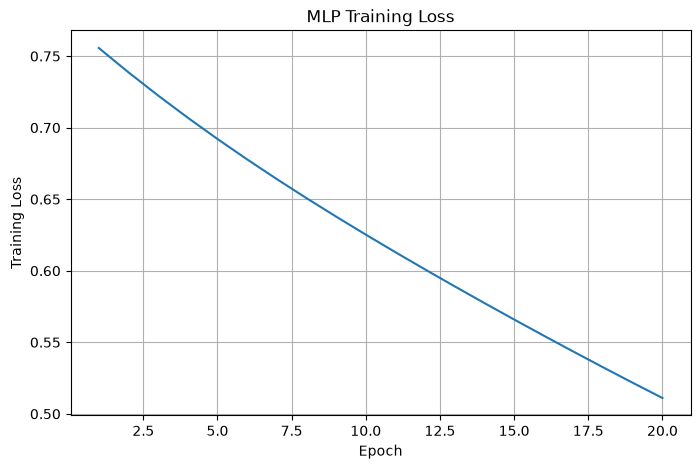

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("MLP Training Loss")

plt.grid(True)
plt.show()

In [27]:
model.eval()

with torch.no_grad():

    test_outputs = model(X_test_tensor)

    predictions = torch.argmax(
        test_outputs,
        dim=1
    )

accuracy = (
    predictions == y_test_tensor
).float().mean()

print(
    f"Test Accuracy: {accuracy.item() * 100:.2f}%"
)

Test Accuracy: 88.57%


## Observations

- The loan default dataset was converted from Pandas data into PyTorch tensors.
- Numerical input features were represented using FloatTensor.
- Target labels were represented using LongTensor.
- A custom Multi-Layer Perceptron was created by subclassing `torch.nn.Module`.
- The network used linear layers with ReLU activation functions.
- The model was trained for 20 epochs using a manual PyTorch training loop.
- Training loss was tracked and visualized using Matplotlib.
- The model was evaluated on the unseen test dataset.

## Conclusion

This project provided a first practical implementation of deep learning using PyTorch. It demonstrated how tensors, neural-network layers, activation functions, loss calculation, backpropagation, and optimizer updates work together in a manual training workflow.